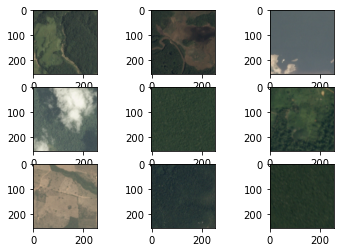

A dimensão do dataframe é:  (40479, 2)
(40479, 128, 128, 3) (40479, 17)


In [1]:
from create_dataset import *
from tensorflow.keras import backend
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import fbeta_score as fbeta
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from datetime import timedelta
import time
from tensorflow.keras import backend

In [2]:
# Para carregar os dados
data = np.load(base_dir +'/amazon_data.npz')
X, y = data['arr_0'], data['arr_1']

In [3]:
print('Dimensões: ')
print('X: ',X.shape, '\n y: ', y.shape)

Dimensões: 
X:  (40479, 128, 128, 3) 
 y:  (40479, 17)


In [4]:
# Separando os dados, apesar de haver uma pasta chamada 'test'
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1)

# Criando o modelo com Dropout

In [6]:
modelo = Sequential()
modelo.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(128,128,3)))
modelo.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Dropout(0.2))
modelo.add(Conv2D(64, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'))
modelo.add(Conv2D(64, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Dropout(0.2))
modelo.add(Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'))
modelo.add(Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Dropout(0.2))
modelo.add(Flatten())
modelo.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
modelo.add(Dropout(0.5))
modelo.add(Dense(17, activation='sigmoid'))
# Compilando
opti = SGD(lr=0.01, momentum=0.9)
modelo.compile(optimizer=opti, loss='binary_crossentropy', metrics=[fbeta])

In [18]:
# calculate fbeta score for multi-class/label classification
def fbeta(y_true, y_pred, beta=2):
    # clip predictions
    y_pred = backend.clip(y_pred, 0, 1)
    # calculate elements
    tp = backend.sum(backend.round(backend.clip(y_true * y_pred, 0, 1)), axis=1)
    fp = backend.sum(backend.round(backend.clip(y_pred - y_true, 0, 1)), axis=1)
    fn = backend.sum(backend.round(backend.clip(y_true - y_pred, 0, 1)), axis=1)
    # calculate precision
    p = tp / (tp + fp + backend.epsilon())
    # calculate recall
    r = tp / (tp + fn + backend.epsilon())
    # calculate fbeta, averaged across each class
    bb = beta ** 2
    fbeta_score = backend.mean((1 + bb) * (p * r) / (bb * p + r + backend.epsilon()))
    return fbeta_score

# Gerando o dataset e normalizando

In [8]:
datagen = ImageDataGenerator(rescale=1.0/255.0)

In [9]:
# Iteradores
train_it = datagen.flow(Xtr, ytr, batch_size=128)
test_it = datagen.flow(Xte, yte, batch_size=128)

In [10]:
Xtr.shape

(28335, 128, 128, 3)

In [10]:
ytr.shape

(28335, 17)

In [ ]:
start_time = time.monotonic()
modelohis = modelo.fit(train_it,
                                steps_per_epoch=len(train_it),
                                validation_data = test_it,
                                validation_steps=len(test_it),
                                epochs=50,
                                verbose=1)
end_time = time.monotonic()
print(timedelta(seconds=end_time - start_time))

Epoch 1/50
  5/222 [..............................] - ETA: 1:30:59 - loss: 0.5742 - fbeta: 0.5197

In [14]:
# plot diagnostic learning curves
def summarize_diagnostics(history):
	# plot loss
	pyplot.subplot(211)
	pyplot.title('Cross Entropy Loss')
	pyplot.plot(history.history['loss'], color='blue', label='train')
	pyplot.plot(history.history['val_loss'], color='orange', label='test')
	# plot accuracy
	pyplot.subplot(212)
	pyplot.title('Fbeta')
	pyplot.plot(history.history['fbeta'], color='blue', label='train')
	pyplot.plot(history.history['val_fbeta'], color='orange', label='test')
	# save plot to file
	filename = sys.argv[0].split('/')[-1]
	pyplot.savefig(filename + '_plot.png')
	pyplot.close()

TypeError: load_dataset() missing 3 required positional arguments: 'path', 'file_mapping', and 'tag_mapping'